# EDA Silver Indicateur 0

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
SILVER_DIR = PROJECT_ROOT / "silver"

In [5]:
def arrondissement_sort_key(path: Path) -> int:
    digits = "".join(character for character in path.stem if character.isdigit())
    return int(digits) if digits else 0

parquet_files = sorted(SILVER_DIR.glob("paris_*.parquet"), key=arrondissement_sort_key)

if not parquet_files:
    raise FileNotFoundError(f"Aucun parquet trouvé dans {SILVER_DIR}")

counts = {}
for parquet_file in parquet_files:
    arrondissement = parquet_file.stem.split("_")[-1]
    df = pd.read_parquet(parquet_file)
    counts[arrondissement] = len(df)

counts = pd.Series(counts).sort_index(key=lambda index: index.map(lambda value: int(value)))
counts.to_frame(name="nombre_de_lignes")

,nombre_de_lignes
01,4424
02,5421
03,8356
04,6776
05,10602
06,11377
07,14950
08,14281
09,16218
10,18718


C:\Users\pasca\AppData\Local\Temp\ipykernel_10444\2092304828.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=palette)


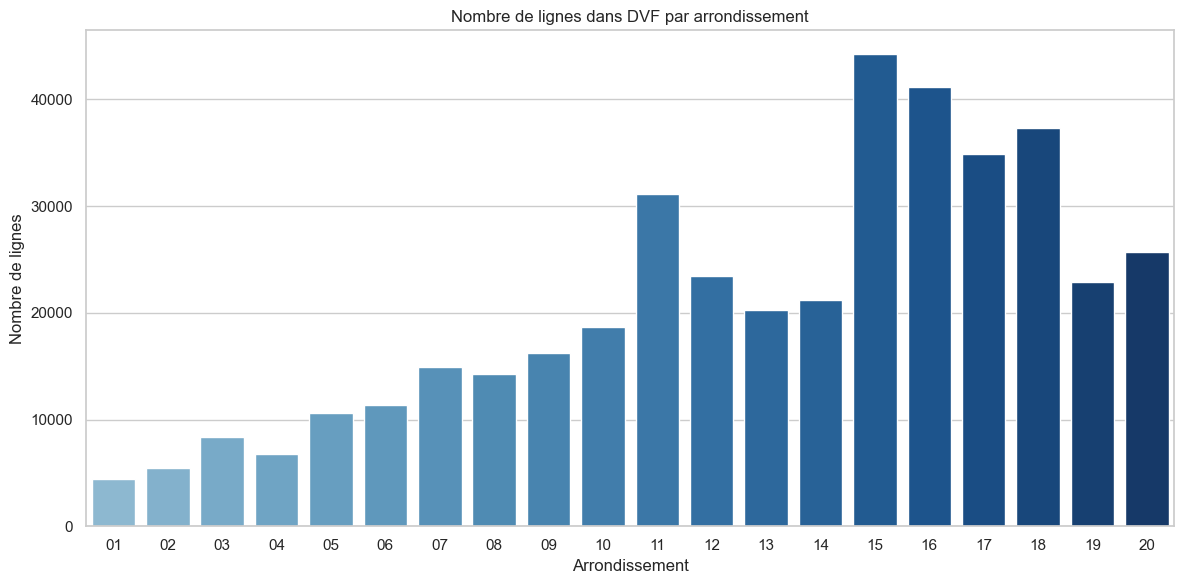

In [6]:
plt.figure(figsize=(12, 6))
palette = sns.color_palette("Blues", n_colors=len(counts) + 15)[15:]
ax = sns.barplot(x=counts.index, y=counts.values, palette=palette)
ax.set_title("Nombre de lignes dans DVF par arrondissement")
ax.set_xlabel("Arrondissement")
ax.set_ylabel("Nombre de lignes")
plt.tight_layout()
plt.show()